In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df = pd.read_csv('/content/Fish (1).csv')
print('Dataset loaded successfull')

Dataset loaded successfull


In [ ]:
df.shape

(159, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [ ]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [ ]:
df.isnull().sum()

,0
Species,0
Weight,0
Length1,0
Length2,0
Length3,0
Height,0
Width,0


In [ ]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [ ]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [ ]:
#Check duplicate records
print(df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

0


In [ ]:
#Outliers
Q1 = df['Length3'].quantile(0.25)
Q3 = df['Length3'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -1.5125000000000064
Upper Bound: 64.38750000000002


In [ ]:
df = df[(df['Length3'] >= lower_bound) & (df['Length3'] <= upper_bound)]
print("Dataset Shape after removing outliers:", df.shape)

Dataset Shape after removing outliers: (157, 7)


In [ ]:
# Independent and Dependent Variables
x = df['Length3']
y = df['Weight']

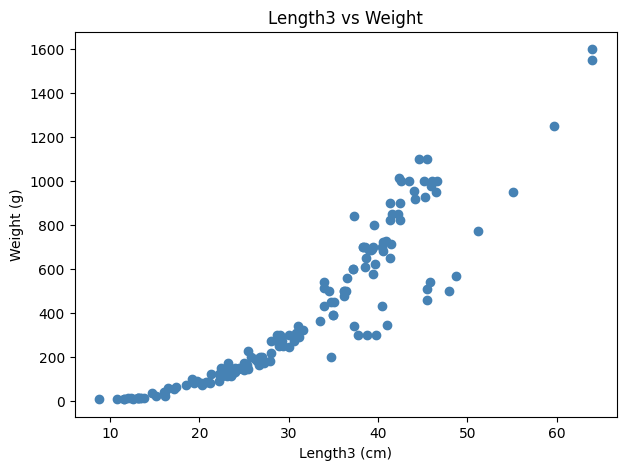

In [ ]:
#Plot between Length3 and Weight
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='steelblue')
plt.xlabel('Length3 (cm)')
plt.ylabel('Weight (g)')
plt.title('Length3 vs Weight')
plt.show()

In [ ]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=123)

In [ ]:
#Training Data
print("First 5 rows of x_train:")
display(x_train.head())

print("\nFirst 5 rows of y_train:")
display(y_train.head())

First 5 rows of x_train:


,Length3
126,46.0
7,35.0
128,34.8
4,34.0
63,19.8



First 5 rows of y_train:


,Weight
126,1000.0
7,390.0
128,200.0
4,430.0
63,90.0


In [ ]:
#Testing data
print("First 5 rows of x_test:")
display(x_test.head())

print("\nFirst 5 rows of y_test:")
display(y_test.head())

First 5 rows of x_test:


,Length3
24,40.5
23,40.6
139,51.2
88,23.5
135,45.5



First 5 rows of y_test:


,Weight
24,700.0
23,680.0
139,770.0
88,130.0
135,510.0


In [ ]:
regression = LinearRegression()
regression.fit(x_train.values.reshape(-1,1),y_train)

print(f"Number of instances for training: {len(x_train)}")
print(f"Number of instances for testing: {len(x_test)}")

Number of instances for training: 125
Number of instances for testing: 32


In [ ]:
poly_features=PolynomialFeatures(degree=3)

In [ ]:
x_poly=poly_features.fit_transform(x_train.values.reshape(-1,1))
regression.fit(x_poly,y_train)

LinearRegression()

In [ ]:
model = LinearRegression()
x_train_poly = poly_features.fit_transform(x_train.values.reshape(-1,1))
model.fit(x_train_poly, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
#predictions
x_test_poly = poly_features.transform(x_test.values.reshape(-1,1))
y_pred = regression.predict(x_test_poly)

In [ ]:
# Generate predictions for the training data
y_train_pred = regression.predict(x_train_poly)
y_test_pred = y_pred

In [ ]:
#Actual vs Predicted
y_pred_for_display = model.predict(x_train_poly)
df = pd.DataFrame({'Actual': y_train,'Predicted': y_pred_for_display})
print(df)

     Actual   Predicted
126  1000.0  886.978838
7     390.0  471.927064
128   200.0  464.791211
4     430.0  436.536918
63     90.0   60.058292
..      ...         ...
17    700.0  600.619608
99    180.0  202.004047
67    170.0  122.323138
127  1000.0  909.674581
110   556.0  526.272901

[125 rows x 2 columns]


In [ ]:
#Evaluation of metrics

# Evaluate model performance on training data
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("\nAfter Model Training:")
print(f"Mean Absolute Error (MAE): {mae_train:.2f}")
print(f"Mean Squared Error (MSE): {mse_train:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.2f}")
print(f"R2 Score: {r2_train:.2f}")

# Evaluate model performance on testing data
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("\nAfter Model Testing:")
print(f"Mean Absolute Error (MAE): {mae_test:.2f}")
print(f"Mean Squared Error (MSE): {mse_test:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.2f}")
print(f"R2 Score: {r2_test:.2f}")


After Model Training:
Mean Absolute Error (MAE): 64.26
Mean Squared Error (MSE): 12610.69
Root Mean Squared Error (RMSE): 112.30
R2 Score: 0.89

After Model Testing:
Mean Absolute Error (MAE): 99.87
Mean Squared Error (MSE): 24428.55
Root Mean Squared Error (RMSE): 156.30
R2 Score: 0.82


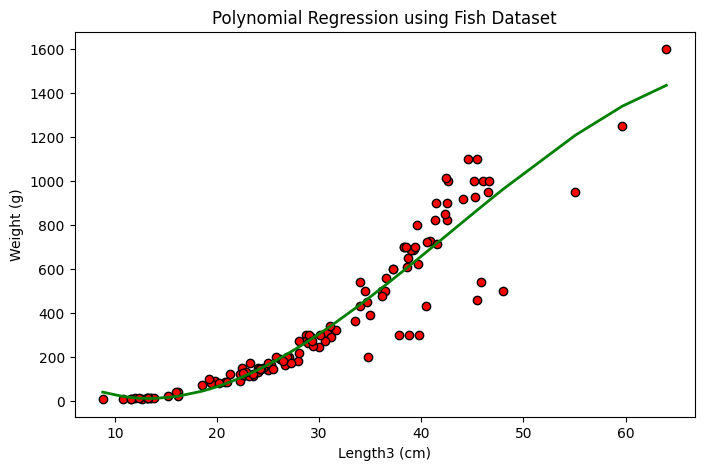

In [ ]:
idx = np.argsort(x_train.values)
x_smooth = x_train.values[idx]
y_smooth = regression.predict(x_poly)[idx]
plt.figure(figsize=(8,5))
plt.scatter(x_train,y_train,color='red',edgecolor='black',label='Actual Data')
plt.plot(x_smooth,y_smooth,color='green',linewidth=2,label='Polynomial Regression Curve')
plt.xlabel("Length3 (cm)")
plt.ylabel("Weight (g)")
plt.title("Polynomial Regression using Fish Dataset")
plt.show()